In [1]:
# ===============================================
# 1) Install And Import Libraries
# ===============================================

!pip install comet_ml --quiet

import shutil
import gc
import comet_ml
comet_ml.login()

import numpy as np
import matplotlib.pyplot as plt
from scipy import io
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.constraints import MaxNorm
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.6/796.6 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.1 MB/s eta 0:00:00
Please paste your Comet API key from https://www.comet.com/api/my/settings/
(api key may not show as you type)
Comet API key: ··········


COMET INFO: Valid Comet API Key saved in /root/.comet.config (set COMET_CONFIG to change where it is saved).


In [2]:
# ===============================================
# 2) Set Random Seed
# ===============================================

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)

In [3]:
# ===============================================
# 3) Model Architecture
# ===============================================

def build_model_graph(experiment):

    reg_name = experiment.get_parameter("k_r")
    reg = regularizers.l1(1e-4) if reg_name == "l1" else regularizers.l2(1e-4)

    model = Sequential()

    model.add(tf.keras.Input(shape=(784,)))

    model.add(Dense(experiment.get_parameter("first_layer_units"),
                    activation='relu',
                    kernel_constraint=MaxNorm(3),
                    kernel_regularizer=reg))

    model.add(Dropout(0.2))

    model.add(Dense(200,
                    activation='relu',
                    kernel_constraint=MaxNorm(3),
                    kernel_regularizer=reg))

    model.add(Dropout(0.2))

    model.add(Dense(10, activation='softmax'))

    model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

    return model

In [4]:
# ===============================================
# 4) Training And Evaluation Functions
# ===============================================

def train(experiment, model, X_tr, Y_tr, epochs):

    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        filepath="/content/best_epoch_model.keras",
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=0
    )

    history = model.fit(
        X_tr, Y_tr,
        batch_size=experiment.get_parameter("batch_size"),
        epochs=epochs,
        validation_split=0.2,
        shuffle=True,
        callbacks=[checkpoint_cb]
    )

    experiment.log_metric("loss", history.history['loss'][-1])
    experiment.log_metric("accuracy", history.history['accuracy'][-1])
    experiment.log_metric("val_loss", history.history['val_loss'][-1])
    experiment.log_metric("val_accuracy", max(history.history['val_accuracy']))

    return history

def evaluate(model, X_te, Y_te):

    score = model.evaluate(X_te, Y_te, verbose=0)

    print("Test Loss:", score[0])
    print("Test Accuracy:", score[1])

    return score

In [5]:
# ===============================================
# 5) Dataset Loading And Preprocessing
# ===============================================

def get_dataset(data_path='/content/Data_hoda_full.mat'):

    data = io.loadmat(data_path)

    x_all = np.squeeze(data['Data'])
    y_all = np.squeeze(data['labels'])

    x_tr = x_all[:10000]
    y_tr = y_all[:10000]
    x_te = x_all[10000:12000]
    y_te = y_all[10000:12000]

    target_size = 28

    def square_and_resize(images, target_size):

        n = images.shape[0]

        max_r, max_c = 0, 0

        for img in images:
            r, c = img.shape

            if r > max_r:
                max_r = r

            if c > max_c:
                max_c = c

        max_dim = max(max_r, max_c)
        H, W = max_dim, max_dim

        processed = np.zeros((n, H, W), dtype=np.float32)

        for i, img in enumerate(images):
            r, c = img.shape

            canvas = np.zeros((H, W), dtype=np.float32)

            r_start = (H - r) // 2
            c_start = (W - c) // 2

            canvas[r_start:r_start + r, c_start:c_start + c] = img.astype(np.float32)
            processed[i] = canvas / 255.0

        processed = processed[..., np.newaxis]

        processed = tf.image.resize(
            processed,
            [target_size, target_size],
            method='area'
        ).numpy()

        processed = np.clip(processed, 0.0, 1.0)
        processed = processed[..., 0].astype(np.float32)

        return processed

    X_tr_img = square_and_resize(x_tr, target_size)
    X_te_img = square_and_resize(x_te, target_size)

    rng = np.random.default_rng(RANDOM_SEED)
    train_indices = rng.permutation(X_tr_img.shape[0])

    X_tr_img = X_tr_img[train_indices]
    y_tr = y_tr[train_indices]

    X_tr = X_tr_img.reshape(X_tr_img.shape[0], -1)
    X_te = X_te_img.reshape(X_te_img.shape[0], -1)

    Y_tr = to_categorical(y_tr, 10)
    Y_te = to_categorical(y_te, 10)

    return X_tr, Y_tr, X_te, Y_te, X_tr_img

X_tr_img shape: (10000, 28, 28)
X_te shape: (2000, 784)


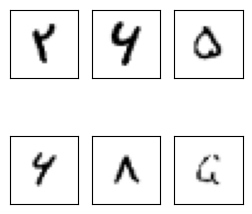

In [6]:
# ===============================================
# 6) Data Visualization
# ===============================================

X_tr, Y_tr, X_te, Y_te, X_tr_img = get_dataset()

print("X_tr_img shape:", X_tr_img.shape)
print("X_te shape:", X_te.shape)

plt.figure(figsize=(3, 3))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_tr_img[i], cmap='binary', aspect='equal')

plt.show()

In [7]:
# ===============================================
# 7) Comet Ml Optimization Setup
# ===============================================

config = {
    "algorithm": "bayes",
    "name": "Optimize My Network",
    "spec": {
        "objective": "maximize",
        "metric": "val_accuracy",
        "maxCombo": 5
    },
    "parameters": {
        "first_layer_units": {"type": "integer", "min": 400, "max": 650},
        "batch_size": {"type": "discrete", "values": [64, 128, 256]},
        "k_r": {"type": "categorical", "values": ["l1", "l2"]},
    },
    "trials": 1,
}

opt = comet_ml.Optimizer(config)

best_val_acc = 0
best_params = None
best_model_path = "/content/best_hoda_model.keras"
EPOCHS = 20

COMET INFO: 6872e59b7fa048739bfa9e9c4bff11bb
COMET INFO: Using optimizer config: {'algorithm': 'bayes', 'configSpaceSize': 'infinite', 'endTime': None, 'id': '6872e59b7fa048739bfa9e9c4bff11bb', 'lastUpdateTime': None, 'maxCombo': 5, 'name': 'Optimize My Network', 'parameters': {'batch_size': {'type': 'discrete', 'values': [64, 128, 256]}, 'first_layer_units': {'max': 650, 'min': 400, 'scalingType': 'uniform', 'type': 'integer'}, 'k_r': {'type': 'categorical', 'values': ['l1', 'l2']}}, 'predictor': None, 'spec': {'gridSize': 10, 'maxCombo': 5, 'metric': 'val_accuracy', 'minSampleSize': 100, 'objective': 'maximize', 'retryAssignLimit': 0, 'retryLimit': 1000}, 'startTime': 250678505, 'state': {'mode': None, 'seed': None, 'sequence': [], 'sequence_i': 0, 'sequence_pid': None, 'sequence_retry': 0, 'sequence_retry_count': 0}, 'status': 'running', 'suggestion_count': 0, 'trials': 1, 'version': '2.3.3.dev26227063361'}


COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/mehdi-moha/general/f81b4af518364d88b496d70e39fd9a28

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
COMET INFO: Ignoring automatic log_parameter('verbose') because 'keras:verbose' is in COMET_LOGGING_PARAMETERS_IGNORE


Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.8430 - loss: 0.6639 - val_accuracy: 0.9360 - val_loss: 0.2835
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9414 - loss: 0.2541 - val_accuracy: 0.9555 - val_loss: 0.2209
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9624 - loss: 0.1906 - val_accuracy: 0.9680 - val_loss: 0.1910
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9688 - loss: 0.1639 - val_accuracy: 0.9675 - val_loss: 0.1800
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9778 - loss: 0.1359 - val_accuracy: 0.9665 - val_loss: 0.1789
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9829 - loss: 0.1217 - val_accuracy: 0.9690 - val_loss: 0.1780
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9854 - loss: 0.1099 - val_accuracy: 0.9705 - val_loss: 0.1698
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9881 - loss: 0.0997 - val_accuracy: 0.9715 - val_loss

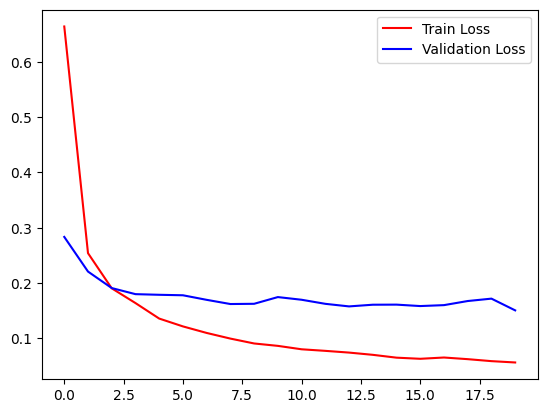

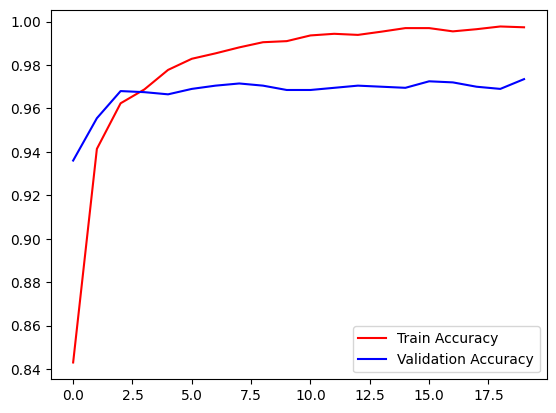

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : electric_arch_8090
COMET INFO:     url                   : https://www.comet.com/mehdi-moha/general/f81b4af518364d88b496d70e39fd9a28
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [21]                : (0.8429999947547913, 0.9977499842643738)
COMET INFO:     batch_accuracy [140]         : (0.140625, 1.0)
COMET INFO:     batch_loss [140]             : (0.056234780699014664, 2.409353256225586)
COMET INFO:     epoch_duration [20]          : (0.30933739699997886, 8.015027811000039)
COMET INFO:     loss [21]                    : (0.05651705339550972, 0.6639240384101868)
COMET INFO:     val_accuracy [21]            : (0.9359999895095825

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.8344 - loss: 0.6714 - val_accuracy: 0.9320 - val_loss: 0.2845
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9446 - loss: 0.2545 - val_accuracy: 0.9590 - val_loss: 0.2128
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9617 - loss: 0.1986 - val_accuracy: 0.9660 - val_loss: 0.1902
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9699 - loss: 0.1662 - val_accuracy: 0.9675 - val_loss: 0.1740
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9790 - loss: 0.1415 - val_accuracy: 0.9665 - val_loss: 0.1753
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9820 - loss: 0.1252 - val_accuracy: 0.9705 - val_loss: 0.1660
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9868 - loss: 0.1100 - val_accuracy: 0.9675 - val_loss: 0.1728
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9870 - loss: 0.1025 - val_accuracy: 0.9665 - val_loss

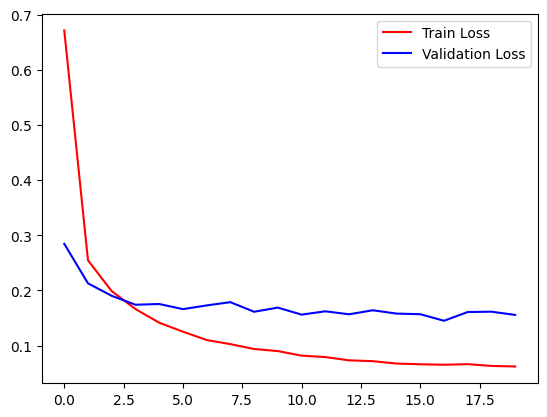

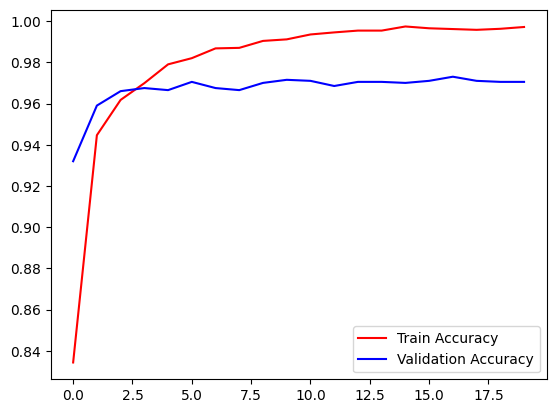

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : concerned_cake_9486
COMET INFO:     url                   : https://www.comet.com/mehdi-moha/general/08eee79149ce4dbebcb233a0ea90824a
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [21]                : (0.8343750238418579, 0.9973750114440918)
COMET INFO:     batch_accuracy [140]         : (0.140625, 1.0)
COMET INFO:     batch_loss [140]             : (0.055809006094932556, 2.3638556003570557)
COMET INFO:     epoch_duration [20]          : (0.3138588119999781, 8.439172428000006)
COMET INFO:     loss [21]                    : (0.062035296112298965, 0.6714434623718262)
COMET INFO:     val_accuracy [21]            : (0.93199998140335

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.8397 - loss: 0.6651 - val_accuracy: 0.9395 - val_loss: 0.2737
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9426 - loss: 0.2532 - val_accuracy: 0.9575 - val_loss: 0.2175
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9646 - loss: 0.1958 - val_accuracy: 0.9670 - val_loss: 0.1913
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9714 - loss: 0.1594 - val_accuracy: 0.9665 - val_loss: 0.1846
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9780 - loss: 0.1403 - val_accuracy: 0.9680 - val_loss: 0.1763
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9821 - loss: 0.1217 - val_accuracy: 0.9715 - val_loss: 0.1724
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9872 - loss: 0.1053 - val_accuracy: 0.9720 - val_loss: 0.1689
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9877 - loss: 0.1007 - val_accuracy: 0.9685 - val_loss

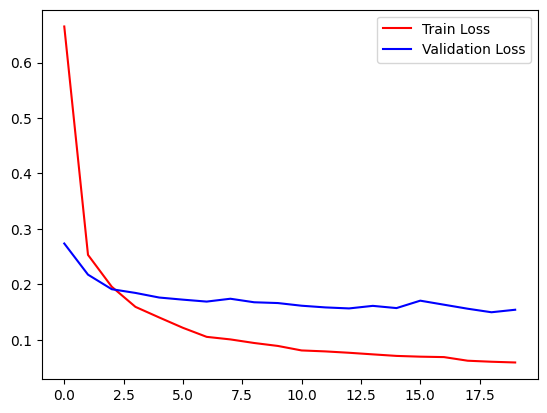

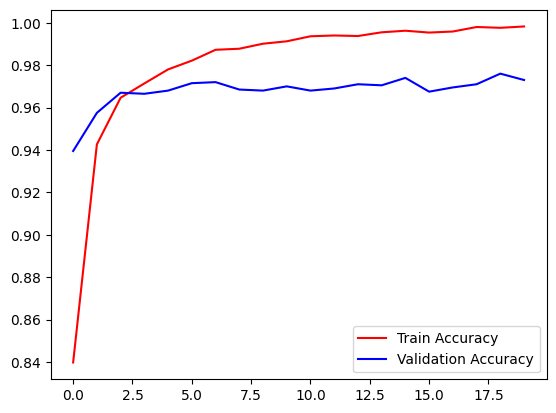

COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : allied_fjord_2088
COMET INFO:     url                   : https://www.comet.com/mehdi-moha/general/9bf99e9510bc4a4399e5d5f6177f21a8
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [21]                : (0.8397499918937683, 0.9982500076293945)
COMET INFO:     batch_accuracy [140]         : (0.15625, 1.0)
COMET INFO:     batch_loss [140]             : (0.055410511791706085, 2.390678644180298)
COMET INFO:     epoch_duration [20]          : (0.31691715599998815, 8.988126571999999)
COMET INFO:     loss [21]             

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.8229 - loss: 1.8675 - val_accuracy: 0.9275 - val_loss: 1.0801
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9330 - loss: 0.9644 - val_accuracy: 0.9495 - val_loss: 0.8472
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9480 - loss: 0.7941 - val_accuracy: 0.9600 - val_loss: 0.7383
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9563 - loss: 0.6926 - val_accuracy: 0.9605 - val_loss: 0.6663
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9640 - loss: 0.6171 - val_accuracy: 0.9635 - val_loss: 0.6017
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9656 - loss: 0.5610 - val_accuracy: 0.9655 - val_loss: 0.5514
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9693 - loss: 0.5110 - val_accuracy: 0.9655 - val_loss: 0.5105
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9701 - loss: 0.4703 - val_accuracy: 0.9695 - val_los

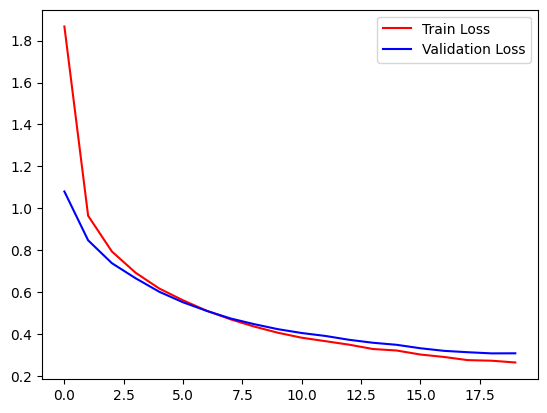

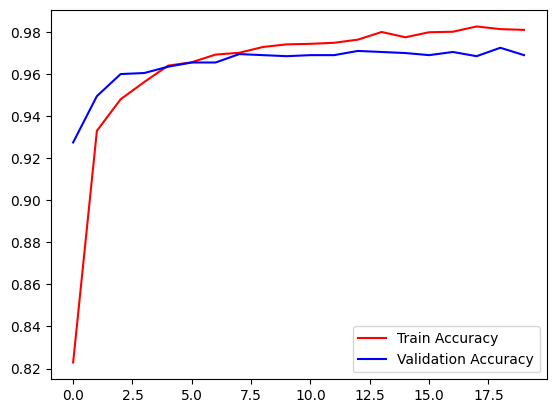

COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : graceful_salmon_6777
COMET INFO:     url                   : https://www.comet.com/mehdi-moha/general/ba3b7dbdb54e47438d796e33fbd17e86
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [21]                : (0.8228750228881836, 0.9826250076293945)
COMET INFO:     batch_accuracy [140]         : (0.078125, 0.9921875)
COMET INFO:     batch_loss [140]             : (0.25968456268310547, 4.168099880218506)
COMET INFO:     epoch_duration [20]          : (0.3087994939999703, 9.262566295)
COMET INFO:     loss [21]           

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step - accuracy: 0.7707 - loss: 2.5125 - val_accuracy: 0.9155 - val_loss: 1.5234
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9250 - loss: 1.2882 - val_accuracy: 0.9410 - val_loss: 1.0667
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9421 - loss: 0.9920 - val_accuracy: 0.9500 - val_loss: 0.9206
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9535 - loss: 0.8609 - val_accuracy: 0.9500 - val_loss: 0.8345
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9594 - loss: 0.7740 - val_accuracy: 0.9560 - val_loss: 0.7552
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9609 - loss: 0.7064 - val_accuracy: 0.9590 - val_loss: 0.6918
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9635 - loss: 0.6494 - val_accuracy: 0.9625 - val_loss: 0.6439
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9669 - loss: 0.5970 - val_accuracy: 0.9630 - val_los

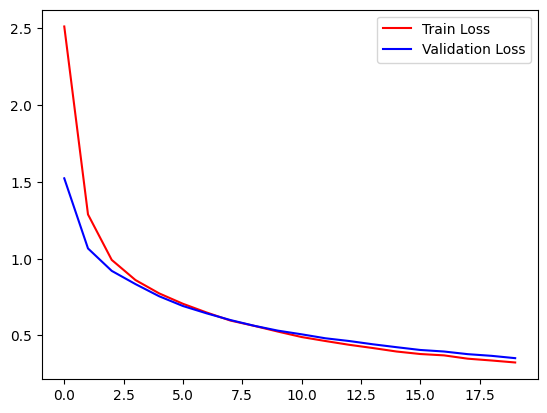

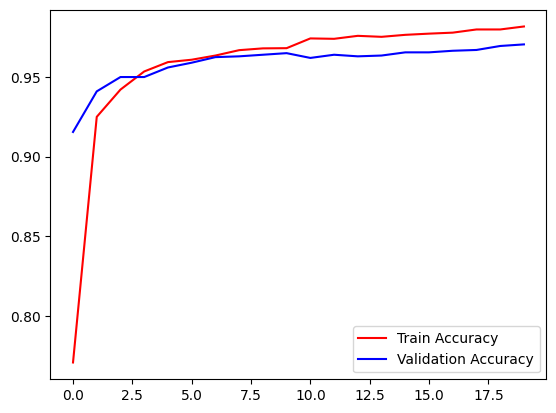

COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : secondary_thrush_8067
COMET INFO:     url                   : https://www.comet.com/mehdi-moha/general/b64e1c2eb4bf403d904feca2e9ef3886
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [21]                : (0.7707499861717224, 0.9817500114440918)
COMET INFO:     batch_accuracy [80]          : (0.078125, 0.98828125)
COMET INFO:     batch_loss [80]              : (0.323889821767807, 4.417474269866943)
COMET INFO:     epoch_duration [20]          : (0.21731797699999333, 8.62090665400001)
COMET INFO:     loss [21]     

In [8]:
# ===============================================
# 8) Run Comet Ml Experiments
# ===============================================

for experiment in opt.get_experiments():

    tf.keras.backend.clear_session()
    gc.collect()

    experiment.log_parameter("epochs", EPOCHS)

    model = build_model_graph(experiment)
    history = train(experiment, model, X_tr, Y_tr, EPOCHS)

    trial_params = {
        "first_layer_units": experiment.get_parameter("first_layer_units"),
        "batch_size": experiment.get_parameter("batch_size"),
        "k_r": experiment.get_parameter("k_r"),
        "epochs": EPOCHS
    }

    val_acc = max(history.history['val_accuracy'])

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = trial_params
        shutil.copy("/content/best_epoch_model.keras", best_model_path)

    plt.figure()
    plt.plot(history.history['loss'], label='Train Loss', color='red')
    plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(history.history['accuracy'], label='Train Accuracy', color='red')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
    plt.legend()
    plt.show()

    experiment.end()

Best Validation Accuracy: 0.9760000109672546
Best Parameters: {'first_layer_units': 619, 'batch_size': 128, 'k_r': 'l2', 'epochs': 20}

Final test evaluation with best model:
Test Loss: 0.21130245923995972
Test Accuracy: 0.9695000052452087

Best Test Accuracy: 0.9695000052452087
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step


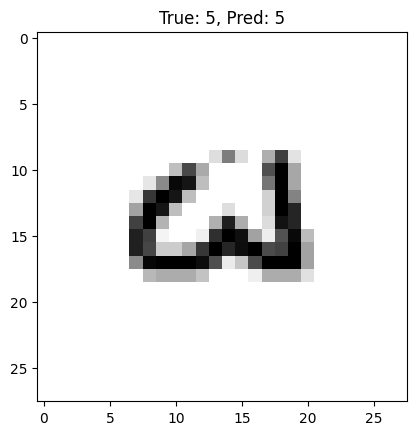

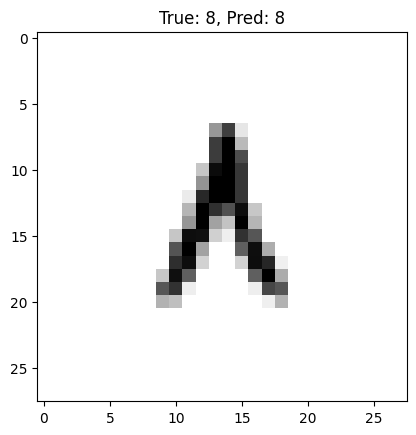

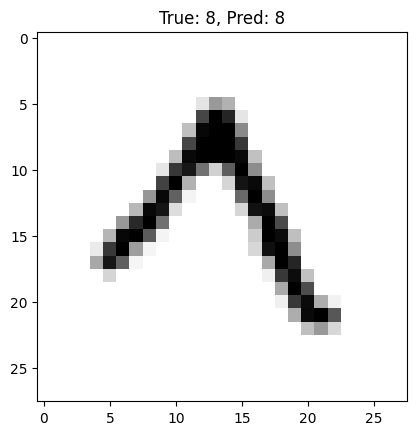

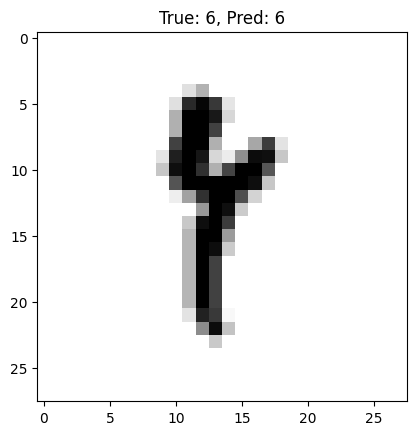

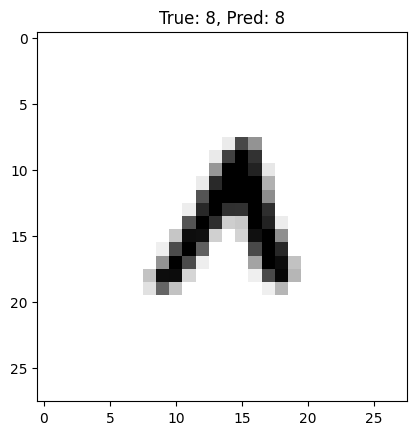

In [9]:
# ===============================================
# 9) Final Evaluation And Prediction
# ===============================================

print("Best Validation Accuracy:", best_val_acc)
print("Best Parameters:", best_params)

best_model = tf.keras.models.load_model(best_model_path)

print("\nFinal test evaluation with best model:")
score = evaluate(best_model, X_te, Y_te)

print("\nBest Test Accuracy:", score[1])

preds = best_model.predict(X_te[:5])

for i in range(5):
    plt.imshow(X_te[i].reshape(28, 28), cmap='binary')
    plt.title(f"True: {np.argmax(Y_te[i])}, Pred: {np.argmax(preds[i])}")
    plt.show()